In [1]:
import os
import sys

os.chdir("..")
sys.path.append("src")

In [2]:
import copy
import torch
import pandas as pd
import matplotlib.pyplot as plt

from wildfire_gnn.utils.config import load_yaml_config
from wildfire_gnn.pipelines.gnn_pipeline import GNNPipeline
from wildfire_gnn.features.feature_engineering import (
    set_feature_names,
    get_feature_names,
    add_degree_feature,
    add_neighborhood_summary_features,
    add_two_hop_summary_features,
    add_feature_interactions,
    subset_graph_features,
)
from wildfire_gnn.data.graph_splitters import (
    attach_masks_from_split_file,
    print_mask_summary,
)

In [3]:
CONFIG_PATH = "configs/gnn_config_gat.yaml"
# alternatives:
# "configs/gnn_config_graphsage.yaml"
# "configs/gnn_config_gat_uncertainty.yaml"

config = load_yaml_config(CONFIG_PATH)
pipeline = GNNPipeline(config)

data = torch.load(
    config["paths"]["graph_data_path"],
    map_location="cpu",
    weights_only=False
)

data = attach_masks_from_split_file(
    data,
    config["paths"]["spatial_split_path"]
)

data = set_feature_names(data, config["data"]["raw_feature_names"])

print(data)
print("x shape:", data.x.shape)
print("y shape:", data.y.shape)
print("edge_index shape:", data.edge_index.shape)
print_mask_summary(data)
print("feature names:", get_feature_names(data))

Data(x=[300000, 7], edge_index=[2, 991684], y=[300000, 1], pos=[300000, 2], num_nodes_original_grid=3589100, num_valid_nodes_before_sampling=702972, num_valid_nodes=300000, reference_height=1900, reference_width=1889, target_name='Burn_Prob.img', feature_names=[7], train_mask=[300000], val_mask=[300000], test_mask=[300000])
x shape: torch.Size([300000, 7])
y shape: torch.Size([300000, 1])
edge_index shape: torch.Size([2, 991684])
Mask summary:
train: 199167
val  : 40718
test : 60115
total: 300000
nodes: 300000
feature names: ['CFL.img', 'FSP_Index.img', 'Ignition_Prob.img', 'Struct_Exp_Index.img', 'Fuel_Models.img', 'row_norm', 'col_norm']


In [4]:
data.y_raw = data.y.clone()

if config["data"].get("target_transform", "none") == "log1p":
    data.y = torch.log1p(data.y)

print("Target stats after transform:")
print("train max raw:", float(data.y_raw[data.train_mask].max()))
print("train max transformed:", float(data.y[data.train_mask].max()))

Target stats after transform:
train max raw: 0.24930262565612793
train max transformed: 0.2225854992866516


In [5]:
if config["feature_engineering"].get("add_degree_feature", False):
    data = add_degree_feature(data)

if config["feature_engineering"].get("add_neighborhood_features", False):
    aggs = set(config["feature_engineering"].get("neighborhood_aggs", []))
    data = add_neighborhood_summary_features(
        data,
        add_mean=("mean" in aggs),
        add_std=("std" in aggs),
        add_max=("max" in aggs),
        add_min=("min" in aggs),
        add_residual=("residual" in aggs),
        add_contrast=("contrast" in aggs),
    )

if config["feature_engineering"].get("add_two_hop_features", False):
    aggs2 = set(config["feature_engineering"].get("two_hop_aggs", []))
    data = add_two_hop_summary_features(
        data,
        add_mean=("mean" in aggs2),
        add_std=("std" in aggs2),
    )

if config["feature_engineering"].get("add_feature_interactions", False):
    data = add_feature_interactions(
        data,
        config["feature_engineering"]["interaction_pairs"]
    )

print("Engineered x shape:", data.x.shape)
print("First 30 feature names:")
print(get_feature_names(data)[:30])

Engineered x shape: torch.Size([300000, 171])
First 30 feature names:
['CFL.img', 'FSP_Index.img', 'Ignition_Prob.img', 'Struct_Exp_Index.img', 'Fuel_Models.img', 'row_norm', 'col_norm', 'degree', 'CFL.img_nbr_mean', 'FSP_Index.img_nbr_mean', 'Ignition_Prob.img_nbr_mean', 'Struct_Exp_Index.img_nbr_mean', 'Fuel_Models.img_nbr_mean', 'row_norm_nbr_mean', 'col_norm_nbr_mean', 'degree_nbr_mean', 'CFL.img_nbr_std', 'FSP_Index.img_nbr_std', 'Ignition_Prob.img_nbr_std', 'Struct_Exp_Index.img_nbr_std', 'Fuel_Models.img_nbr_std', 'row_norm_nbr_std', 'col_norm_nbr_std', 'degree_nbr_std', 'CFL.img_nbr_max', 'FSP_Index.img_nbr_max', 'Ignition_Prob.img_nbr_max', 'Struct_Exp_Index.img_nbr_max', 'Fuel_Models.img_nbr_max', 'row_norm_nbr_max']


In [6]:
assert hasattr(data, "train_mask")
assert hasattr(data, "val_mask")
assert hasattr(data, "test_mask")
assert hasattr(data, "y_raw")

assert int(data.train_mask.sum() + data.val_mask.sum() + data.test_mask.sum()) == data.num_nodes
print("All graph masks and targets are ready.")

All graph masks and targets are ready.


In [7]:
stage = "stage1" if "graphsage" in CONFIG_PATH else "stage2"

train_outputs = pipeline.train(data, stage=stage)
train_outputs.history.tail()

,epoch,train_loss,val_loss
6,7,0.001619,0.00168
7,8,0.001619,0.00168
8,9,0.001618,0.00168
9,10,0.001618,0.00168
10,11,0.001618,0.00168


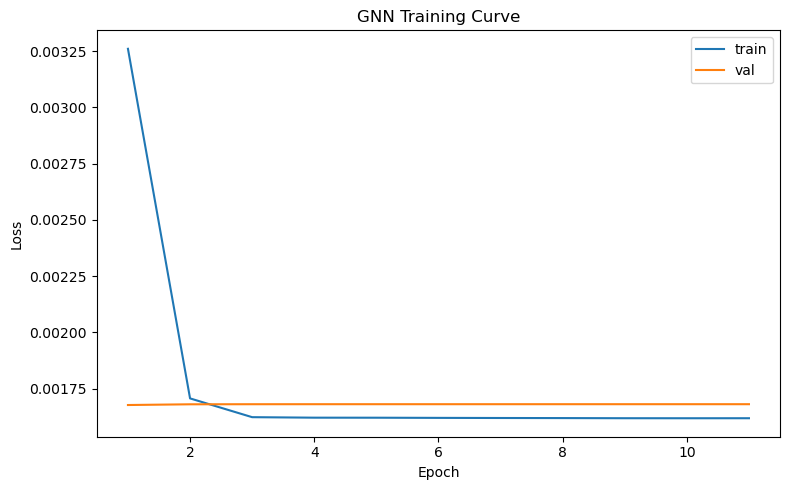

In [8]:
hist = train_outputs.history

plt.figure(figsize=(8, 5))
plt.plot(hist["epoch"], hist["train_loss"], label="train")
plt.plot(hist["epoch"], hist["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("GNN Training Curve")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
metrics = pipeline.evaluate(
    data=data,
    checkpoint_path=train_outputs.best_model_path,
    stage=stage,
)
metrics